# Load OSN response to acetophenone

In [2]:
import pandas as pd
T6 = r'C:\Users\duble\Dropbox\ORFigures\Figures2024\Tables\Table S6.xlsx'
df = pd.read_excel(T6, sheet_name=0,skiprows=1)
# Display the first few rows of the DataFrame
print(df.head())


   OSN type   Response to 1% acetophenone - mouse #1  \
0     Olfr1                                 0.043062   
1    Olfr10                                 0.000000   
2   Olfr100                                 0.033210   
3  Olfr1000                                 0.500000   
4  Olfr1002                                 0.000000   

    Total number of OSNs mapped in mouse #1  \
0                                       418   
1                                        12   
2                                       542   
3                                         4   
4                                         6   

    Response to 1% acetophenone - mouse #2  \
0                                 0.042705   
1                                 0.166667   
2                                 0.012605   
3                                 0.000000   
4                                 0.000000   

    Total number of OSNs mapped in mouse #2  \
0                                       281   
1        

Text(0, 0.5, 'Response to 1% acetophenone - mouse #2')

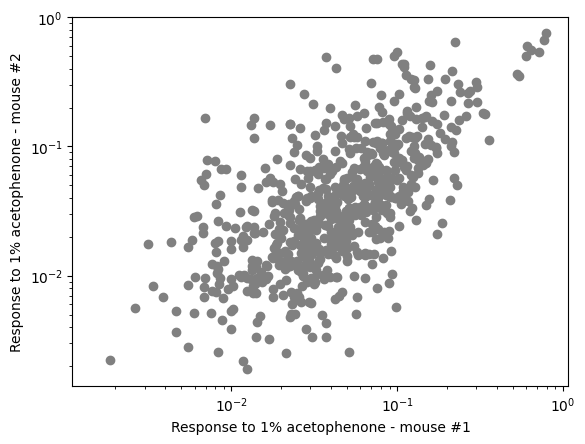

In [20]:
ORs = df['OSN type']
R1 = df[" Response to 1% acetophenone - mouse #1"]
R2 = df[" Response to 1% acetophenone - mouse #2"]
R3 = df[" Response to 100% acetophenone - mouse #3"]
R4 = df[" Response to 100% acetophenone - mouse #4"]
import numpy as np
Rm1 = np.log((R1+R2)/2)
Rm100 = np.log((R3+R4)/2)
import matplotlib.pylab as plt
plt.loglog(R1,R2,'o',c='gray')
plt.xlabel('Response to 1% acetophenone - mouse #1')
plt.ylabel('Response to 1% acetophenone - mouse #2')

In [18]:
rodriguez_olfrs = ['Olfr145', 'Olfr736', 'Olfr901', 'Olfr983', 'Olfr556', 'Olfr476', 'Olfr1501', 'Olfr1484', 'Olfr478', 'Olfr922', 'Olfr378', 'Olfr229', 'Olfr750', 'Olfr19', 'Olfr160', 'Olfr490', 'Olfr935', 'Olfr745', 'Olfr47', 'Olfr109', 'Olfr1377', 'Olfr1135', 'Olfr143', 'Olfr1350', 'Olfr1054', 'Olfr30', 'Olfr366', 'Olfr1087', 'Olfr1085', 'Olfr142', 'Olfr1459', 'Olfr1014', 'Olfr1477', 'Olfr874', 'Olfr943', 'Olfr923', 'Olfr849', 'Olfr452', 'Olfr1269', 'Olfr895', 'Olfr114', 'Olfr870', 'Olfr1231', 'Olfr933', 'Olfr488']
matsunami_olfrs = ['Olfr376', 'Olfr19', 'Olfr749', 'Olfr923', 'Olfr30', 'Olfr1047', 'Olfr136', 'Olfr1104', 'Olfr744', 'Olfr110', 'Olfr875', 'Olfr895', 'Olfr490', 'Olfr874', 'Olfr876', 'Olfr983', 'Olfr1477', 'Olfr1463', 'Olfr1448', 'Olfr1377', 'Olfr430', 'Olfr160', 'Olfr1009', 'Olfr935', 'Olfr133', 'Olfr491', 'Olfr1333', 'Olfr1054', 'Olfr1094', 'Olfr502', 'Olfr62', 'Olfr1444', 'Olfr205', 'Olfr44', 'Olfr920', 'Olfr191', 'Olfr1238', 'Olfr746', 'Olfr904', 'Olfr736', 'Olfr60', 'Olfr145', 'Olfr887', 'Olfr1484', 'Olfr1093']

In [24]:
dic_fr_act = {o:np.nanmean([r1,r2])for o,r1,r2 in zip(ORs,R3,R4)}

C:\Users\duble\AppData\Local\Temp\ipykernel_35712\1685409939.py:1: RuntimeWarning: Mean of empty slice
  dic_fr_act = {o:np.nanmean([r1,r2])for o,r1,r2 in zip(ORs,R3,R4)}


Text(42.722222222222214, 0.5, 'Response')

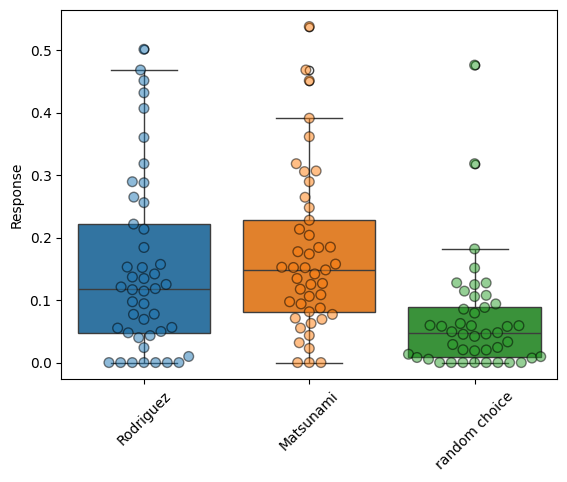

In [29]:
import seaborn as sns
np.random.seed(1) 
dt_random = np.random.choice([dic_fr_act.get(o) for o in dic_fr_act],len(matsunami_olfrs))#,random_state=10)
data = [[dic_fr_act.get(o) for o in rodriguez_olfrs],
                   [dic_fr_act.get(o) for o in matsunami_olfrs],dt_random]
fig = plt.figure()
ax = sns.swarmplot(data=data,s=7,edgecolor=[0,0,0],linewidth=1,alpha=0.5)
sns.boxplot(data=data)
plt.xticks([0,1,2],['Rodriguez','Matsunami','random choice'],rotation=45)
plt.ylabel('Response')
